In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("ggplot")
sns.set_palette("Set2")

In [4]:
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled orders
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Keep only positive Quantity and UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

print(df.shape)

(397884, 8)


In [ ]:
# RFM (Recency, Frequency, Monetary) Analysis
# RFM analysis is a widely used customer segmentation technique where:
# - Recency (R):** How recently a customer made a purchase.
# - Frequency (F):** How often a customer makes purchases.
# - **Monetary (M):** How much money a customer has spent.
# These three features are used to group customers with similar purchasing behaviour.

In [8]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Total Amount column
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Reference date (one day after the latest transaction)
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:
print("Average Purchase Value:", round(df["TotalAmount"].mean(), 2))
print("Average Purchase Frequency:", round(rfm["Frequency"].mean(), 2))
print("Average Customer Lifetime Value:", round(rfm["Monetary"].mean(), 2))

Average Purchase Value: 22.4
Average Purchase Frequency: 4.27
Average Customer Lifetime Value: 2054.27


In [10]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


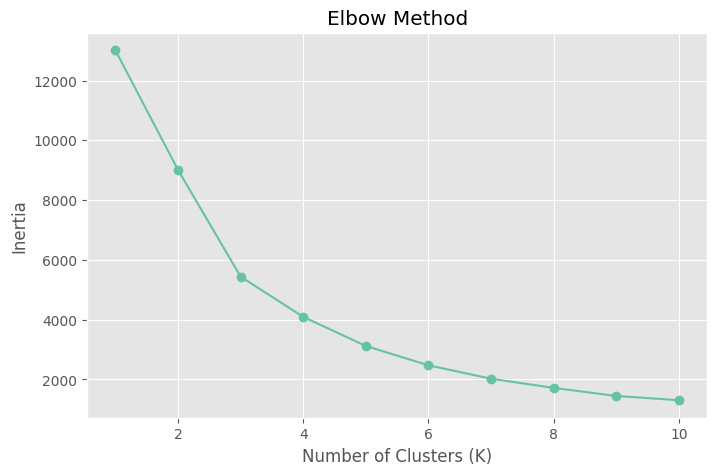

In [11]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


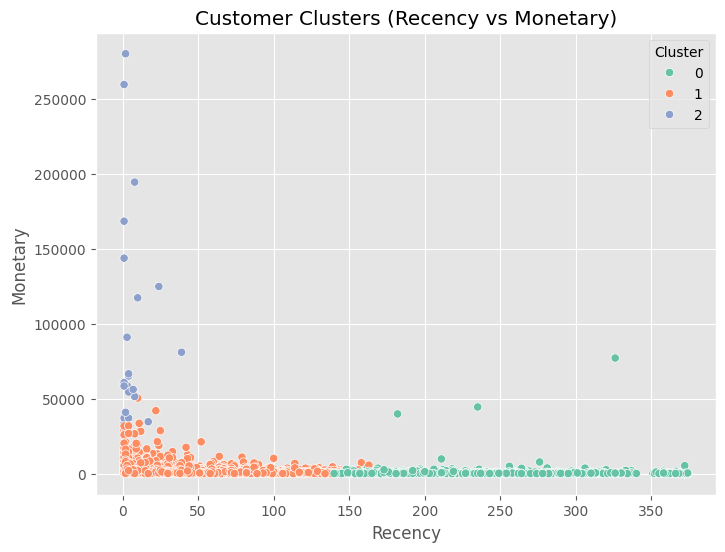

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Clusters (Recency vs Monetary)")
plt.show()

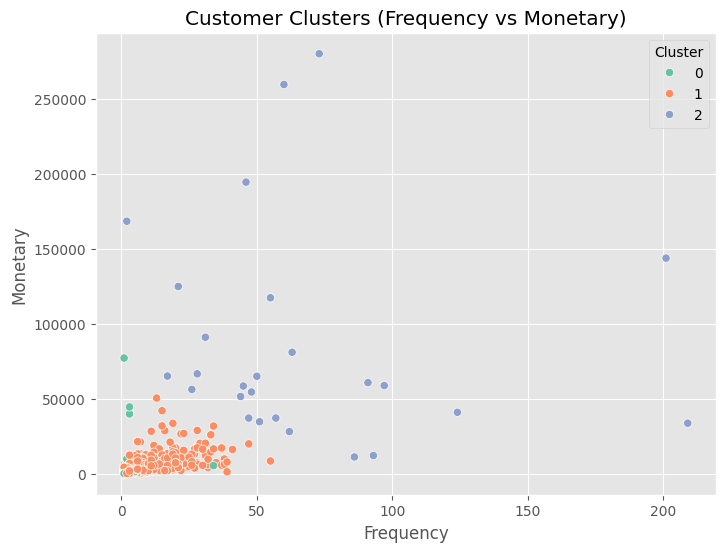

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Clusters (Frequency vs Monetary)")
plt.show()

In [15]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,247.106285,1.582255,631.424206
1,41.454180,4.672755,1855.942345
2,6.038462,66.423077,85904.351538


/var/folders/yq/y_0rqk493w7b4qy8mc1qjqbh0000gn/T/ipykernel_89025/4070886535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


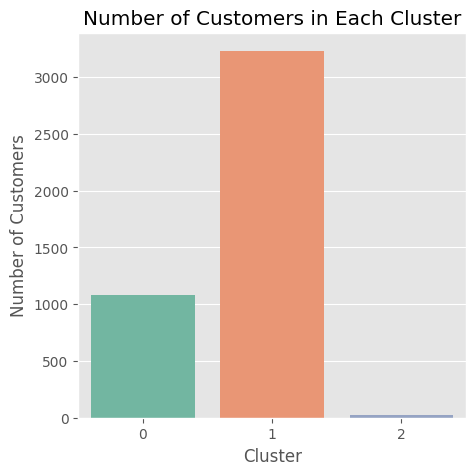

In [26]:
plt.figure(figsize=(5,5))

sns.countplot(
    x="Cluster",
    data=rfm,
    palette="Set2"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()